In [1]:
# Import von Bibliotheken
import io,re
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

In [2]:
# Einlesen der Langwahlprogramme (aus JSON-Format)

# für CDU/CSU
with open("cdu-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    CDU_text_json = json.load(datei)

# für SPD
with open("spd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    SPD_text_json = json.load(datei)

# für Die Linke
with open("linke-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Linke_text_json = json.load(datei)

# für die AfD
with open("afd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    AfD_text_json = json.load(datei)

# für Bündnis 90/Grüne
with open("gruene-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Grüne_text_json = json.load(datei)

# für FDP
with open("fdp-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    FDP_text_json = json.load(datei)

In [3]:
# Überführen aller 'eigentlichen' Texte in eine Liste pro Partei, d.h. ohne Kapitelüberschriften

# Such-/Filterfunktion
def finde_gefilterte_texte(struktur):
    ergebnisse = []
    
    # Fall A: Wenn das aktuelle Element ein Dictionary ist
    if isinstance(struktur, dict):
        # Typ/Art auslesen (liefert None, wenn der Schlüssel fehlt)
        aktueller_typ = struktur.get('type') or struktur.get('art')            # nur Suchen in diesen Elementen
        
        # Prüfen, ob 'text' existiert und der gefundene Typ gültig ist
        if 'text' in struktur and aktueller_typ in ['paragraph', 'bullet', 'absatz']:   # nur Texte überführen mit diesem Typ
            ergebnisse.append(struktur['text'])
        
        # Tiefer in alle Werte schauen für eventuelle Verschachtelungen
        for wert in struktur.values():
            ergebnisse.extend(finde_gefilterte_texte(wert))
                
    # Fall B: Wenn das aktuelle Element eine Liste ist
    elif isinstance(struktur, list):
        for element in struktur:
            ergebnisse.extend(finde_gefilterte_texte(element))
            
    return ergebnisse

CDU_text = finde_gefilterte_texte(CDU_text_json)
CDU_text = CDU_text[135:]   # da vor der eigentlichen Langfassung im CDU/CSU-Programm noch eine Kurzfassung vorangeht, wird diese ausgeblendet
SPD_text = finde_gefilterte_texte(SPD_text_json)
Linke_text = finde_gefilterte_texte(Linke_text_json)
Grüne_text = finde_gefilterte_texte(Grüne_text_json)
AfD_text = finde_gefilterte_texte(AfD_text_json)
FDP_text = finde_gefilterte_texte(FDP_text_json)

In [4]:
# Übersicht, wie hoch der Anteil unterschiedlicher Längen am Gesamtkorpus ist - pro Partei

bins = [0, 100, 200, 300, 400, 500, 600, 700, float('inf')]

# Partei-Serien in ein Dictionary packen
parteien_dict = {
    'CDU': pd.Series(CDU_text),
    'SPD': pd.Series(SPD_text),
    'Linke': pd.Series(Linke_text),
    'Grüne': pd.Series(Grüne_text),
    'AfD': pd.Series(AfD_text),
    'FDP': pd.Series(FDP_text)
}

# Haupttabelle: Bins pro Partei zählen
df_ergebnis = pd.DataFrame({
    partei: pd.cut(serie.str.len(), bins=bins).value_counts().sort_index()
    for partei, serie in parteien_dict.items()
})

# Index ohne Nachkommastellen formatieren
neuer_index = []
for intervall in df_ergebnis.index:
    links = int(intervall.left)
    rechts = "inf" if intervall.right == float('inf') else int(intervall.right)
    neuer_index.append(f"({links}, {rechts}]")

df_ergebnis.index = neuer_index

# Kennzahlen berechnen
mittelwerte = {}
prozent_bis_500 = {}
gesamtzahl = {}

for partei, serie in parteien_dict.items():
    längen = serie.str.len()
    
    # Mittelwert & Gesamtzahl
    mittelwerte[partei] = längen.mean()
    gesamtzahl[partei] = längen.count()
    
    # Prozentsatz der Absätze bis inkl. 500 Zeichen berechnen
    anzahl_bis_500 = (längen <= 500).sum()
    if gesamtzahl[partei] > 0:
        prozent_bis_500[partei] = (anzahl_bis_500 / gesamtzahl[partei]) * 100
    else:
        prozent_bis_500[partei] = 0

# Kennzahlen als neue Zeilen anhängen
df_ergebnis.loc['Mittelwert (Ø Zeichen)'] = mittelwerte
df_ergebnis.loc['Anteil bis 500 Zeichen (in %)'] = prozent_bis_500
df_ergebnis.loc['Gesamtzahl Absätze'] = gesamtzahl

# Indexname setzen
df_ergebnis.index.name = 'Zeichenintervall / Kennzahl'

# Alle Werte in der Tabelle runden und in Ganzzahlen (int) konvertieren
df_ergebnis = df_ergebnis.round(0).astype(int)

# Ausgabe anzeigen
print(df_ergebnis)

                               CDU  SPD  Linke  Grüne  AfD  FDP
Zeichenintervall / Kennzahl                                    
(0, 100]                       123   15     30      9  114    1
(100, 200]                      89   56    127     35  193    2
(200, 300]                     171   85    153     41  133   14
(300, 400]                     126   67    104     76   99   20
(400, 500]                      88   55     90     73   55   19
(500, 600]                      36   50     57     72   48   24
(600, 700]                      15   32     43     62   30   25
(700, inf]                      12   84     61    215   45   95
Mittelwert (Ø Zeichen)         281  465    380    650  300  752
Anteil bis 500 Zeichen (in %)   90   63     76     40   83   28
Gesamtzahl Absätze             660  444    665    583  717  200


TypeError: FigureCanvasAgg.print_jpg() got an unexpected keyword argument 'quality'

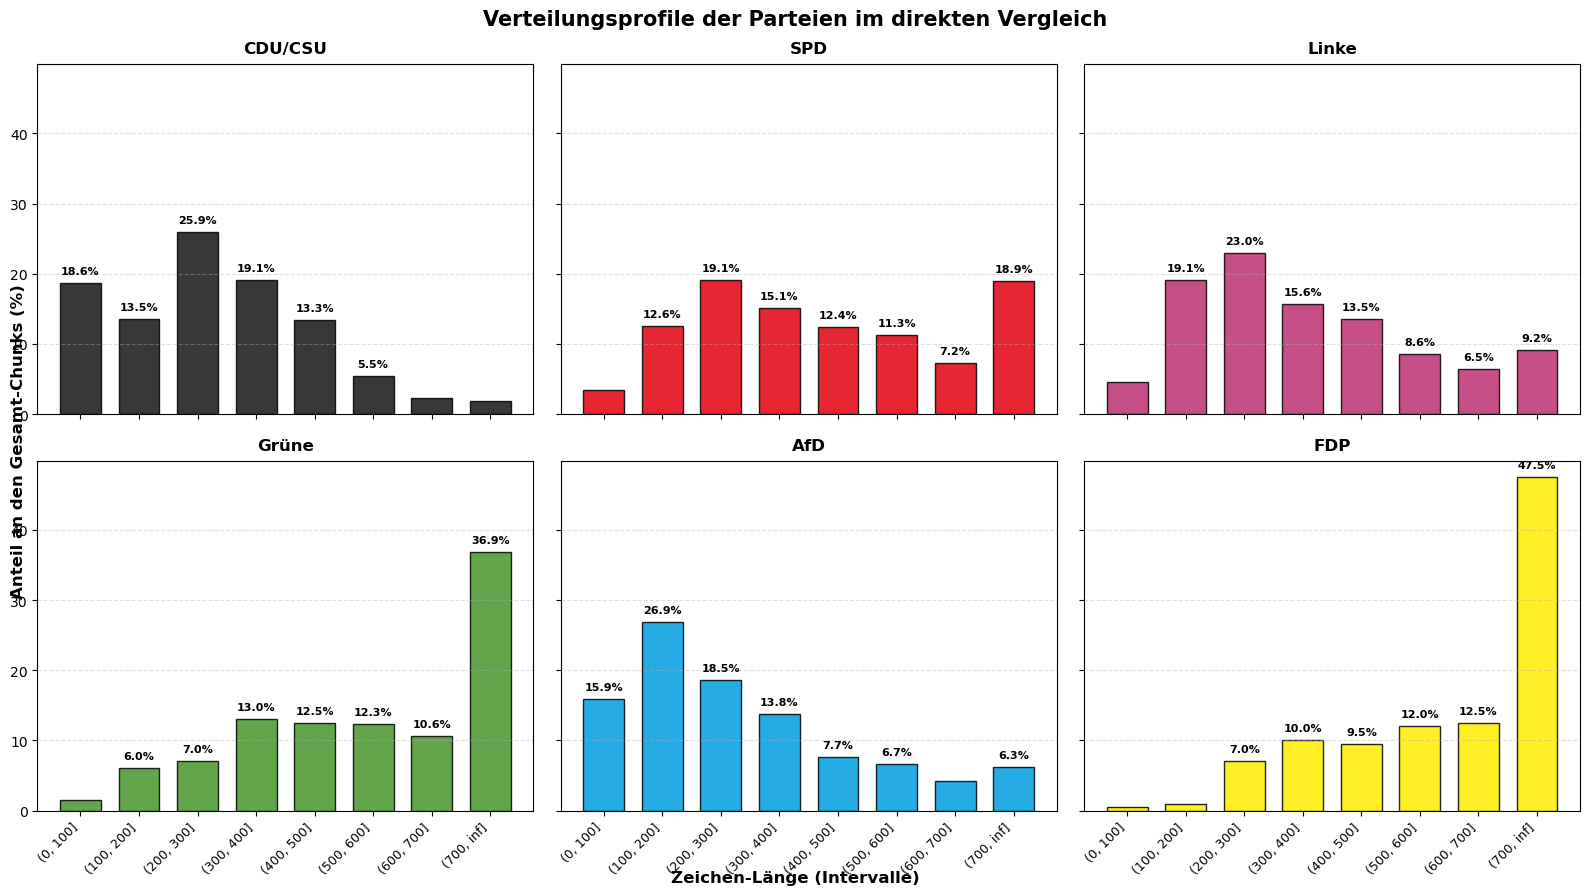

In [5]:
# 1. Daten für alle Parteien definieren (8 Intervalle)
data = {
    "CDU/CSU": [123,  89, 171, 126,  88,  36,  15,  12],
    "SPD":     [ 15,  56,  85,  67,  55,  50,  32,  84],
    "Linke":   [ 30, 127, 153, 104,  90,  57,  43,  61],
    "Grüne":   [  9,  35,  41,  76,  73,  72,  62, 215],
    "AfD":     [114, 193, 133,  99,  55,  48,  30,  45],
    "FDP":     [  1,   2,  14,  20,  19,  24,  25,  95]
}

colors = {
    "CDU/CSU": "#151518", "SPD": "#E3000F", "Linke": "#BE3075",
    "Grüne": "#46962B", "AfD": "#009EE0", "FDP": "#FFED00"
}

bins_labels = ["(0, 100]", "(100, 200]", "(200, 300]", "(300, 400]", "(400, 500]", "(500, 600]", "(600, 700]", "(700, inf]"]
x = np.arange(len(bins_labels))

# Raster erstellen: 2 Zeilen, 3 Spalten
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()  # Flach machen für leichtere Iteration

# Höchsten Prozentwert ermitteln für einheitliche Achsenskalierung
max_prozent = 0
transformed_data = {}
for partei, counts in data.items():
    total = sum(counts)
    prozent_werte = [(c / total) * 100 for c in counts]
    transformed_data[partei] = prozent_werte
    max_prozent = max(max_prozent, max(prozent_werte))

# Plots für jede Partei zeichnen
for i, (partei, prozent_werte) in enumerate(transformed_data.items()):
    ax = axes[i]
    bars = ax.bar(x, prozent_werte, color=colors[partei], edgecolor='black', alpha=0.85, width=0.7)
    
    # Text-Labels auf den wichtigsten Spitzen-Balken platzieren (> 5%)
    for bar in bars:
        h = bar.get_height()
        if h > 5:
            ax.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
            
    ax.set_title(partei, fontsize=12, fontweight='bold', pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(bins_labels, rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Globale Achsenbeschriftungen setzen
fig.text(0.5, 0.01, 'Zeichen-Länge (Intervalle)', ha='center', fontsize=12, fontweight='bold')
fig.text(0.01, 0.5, 'Anteil an den Gesamt-Chunks (%)', va='center', rotation='vertical', fontsize=12, fontweight='bold')
fig.suptitle('Verteilungsprofile der Parteien im direkten Vergleich', fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('chunks_parteien_raster_vergleich_ORIGINAL.png', dpi=300, bbox_inches='tight')
plt.savefig('chunks_parteien_raster_vergleich_ORIGINAL.jpg', dpi=300, quality=95, bbox_inches='tight')

plt.close()